# 17. Solución End-to-End y simulación de pseudo-producción

Este notebook integra los principales componentes desarrollados durante el proyecto en una solución reproducible para la clasificación automática de la calidad de las mediciones de irradiancia solar.

A diferencia de las etapas anteriores, el objetivo no es seleccionar, optimizar o interpretar nuevos modelos, sino utilizar las configuraciones finales ya seleccionadas dentro de un flujo completo de inferencia.

Para ello, se adopta **diciembre de 2024 como periodo de pseudo-producción**. Los modelos finales se reconstruyen manteniendo fijos sus algoritmos, variables e hiperparámetros y se reentrenan utilizando únicamente los datos disponibles hasta el 30 de noviembre de 2024. Posteriormente, se generan las predicciones sobre diciembre y se monitoriza su comportamiento tanto a nivel mensual como diario.

Esta prueba debe entenderse como una **simulación retrospectiva de funcionamiento en producción**, y no como un conjunto de test completamente independiente del proceso experimental global, ya que diciembre pertenece al conjunto de datos disponible durante el desarrollo previo del proyecto.

El flujo evaluado es:

**datos históricos → preparación → reentrenamiento final → inferencia → monitorización → persistencia de resultados**

## 17.1. Objetivos

Los objetivos de este notebook son:

- reconstruir los modelos finales con las configuraciones seleccionadas previamente;
- reentrenarlos con toda la información disponible hasta el 30 de noviembre de 2024;
- simular la inferencia sobre un periodo temporal posterior;
- generar automáticamente los códigos de calidad de GHI, DNI y DHI;
- monitorizar el rendimiento global y su evolución diaria;
- identificar comportamientos anómalos durante la pseudo-producción;
- generar resultados reutilizables para su persistencia y posterior explotación.

Diciembre de 2024 no se utiliza en este notebook para modificar modelos, seleccionar variables ni reajustar hiperparámetros.

In [ ]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier

from src.preprocessing.model_preprocessing import (
    convert_model_dtypes,
    prepare_model_features,
)

from src.models.mlp import (
    build_optimized_mlp,
    get_class_weights,
)

from src.evaluation.evaluation import evaluate_predictions

In [69]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

DATA_PATH = Path(
    "../data/processed/dataset_solar_2023_2024_v3.parquet"
)

MODEL_METADATA_PATH = Path(
    "../models/final/model_metadata.json"
)

TARGETS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi",
]

In [70]:
df = pd.read_parquet(DATA_PATH)

with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as f:
    model_metadata = json.load(f)

## 17.2. Escenario de pseudo-producción

Se establece el **1 de diciembre de 2024** como fecha simulada de puesta en funcionamiento de la solución. Los 1.008.000 registros anteriores se utilizan para el reentrenamiento final, mientras que las 44.640 observaciones de diciembre se reservan para ejecutar y monitorizar el pipeline.

La separación temporal reproduce el comportamiento que tendría el sistema al recibir observaciones posteriores a la última fecha utilizada en su reentrenamiento.

In [71]:
PRODUCTION_START = pd.Timestamp("2024-12-01")

PRODUCTION_END = pd.Timestamp("2025-01-01")

df_historical = (
    df[
        df["fecha"] < PRODUCTION_START
    ]
    .copy()
    .reset_index(drop=True)
)

df_production = (
    df[
        (df["fecha"] >= PRODUCTION_START)
        & (df["fecha"] < PRODUCTION_END)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Histórico: {len(df_historical):,}"
)

print(
    f"Producción: {len(df_production):,}"
)

Histórico: 1,008,000
Producción: 44,640


In [72]:
df_historical_model = convert_model_dtypes(
    df_historical.copy()
)

df_production_model = convert_model_dtypes(
    df_production.copy()
)

## 17.3. Reconstrucción de los modelos finales

Se recuperan los modelos, variables e hiperparámetros seleccionados en las etapas anteriores. Estas decisiones permanecen congeladas durante todo el experimento.

Los modelos HistGradientBoosting de DNI y DHI se reentrenan directamente con el histórico completo. Para GHI se reconstruye la MLP optimizada, incluyendo su arquitectura, regularización, tasa de aprendizaje, tamaño de batch y número de épocas seleccionados previamente.

De esta forma, el notebook no introduce una nueva fase de optimización, sino que reproduce la preparación previa al despliegue de los modelos ya seleccionados.

In [73]:
final_config = {}

for target in TARGETS:

    config = model_metadata[target]

    final_config[target] = {
        "model": config["model"],
        "features": config["features"],
        "hyperparameters": config[
            "hyperparameters"
        ],
    }

    print(
        f"{target}: "
        f"{config['model']} | "
        f"{len(config['features'])} features"
    )

codigo_ghi: MLP | 14 features
codigo_dni: HistGradientBoostingClassifier | 18 features
codigo_dhi: HistGradientBoostingClassifier | 21 features


In [74]:
models_retrained = {}
production_sets = {}
scalers = {}

for target in TARGETS:

    if (
        final_config[target]["model"]
        != "HistGradientBoostingClassifier"
    ):
        continue

    features = final_config[target][
        "features"
    ]

    (
        X_train,
        X_production,
        used_features,
        _,
    ) = prepare_model_features(
        train_df=df_historical_model,
        test_df=df_production_model,
        features=features,
        accepts_nan=True,
        scale=False,
    )

    y_train = (
        df_historical_model[target]
        .to_numpy()
    )

    params = (
        final_config[target][
            "hyperparameters"
        ]
        .copy()
    )

    params.pop("model", None)

    params.setdefault(
        "random_state",
        RANDOM_STATE,
    )

    model = HistGradientBoostingClassifier(
        **params
    )

    model.fit(
        X_train,
        y_train,
    )

    models_retrained[target] = model

    production_sets[target] = {
        "X": X_production,
        "y": df_production_model[
            target
        ].to_numpy(),
        "features": used_features,
    }

    print(
        f"{target}: "
        f"{len(X_train):,} train | "
        f"{len(X_production):,} producción"
    )

codigo_dni: 1,008,000 train | 44,640 producción
codigo_dhi: 1,008,000 train | 44,640 producción


In [75]:
MLP_TARGET = "codigo_ghi"

ghi_config = final_config[
    MLP_TARGET
]

ghi_features = ghi_config[
    "features"
]

ghi_params = ghi_config[
    "hyperparameters"
].copy()

ghi_params.pop(
    "model",
    None,
)

hidden_units = ghi_params[
    "hidden_units"
]

if isinstance(
    hidden_units,
    str,
):
    hidden_units = json.loads(
        hidden_units
    )

hidden_units = tuple(
    hidden_units
)

print("Configuración final GHI:")
print(ghi_params)

Configuración final GHI:
{'hidden_units': [128, 64], 'dropout_rate': 0.5, 'l2_strength': 0.0001, 'learning_rate': 0.0001, 'batch_size': 512, 'class_weight_mode': 'none', 'epochs': 6}


In [76]:
(
    X_train_final,
    X_production_ghi,
    used_features_ghi,
    scaler_ghi,
) = prepare_model_features(
    train_df=df_historical_model,
    test_df=df_production_model,
    features=ghi_features,
    accepts_nan=False,
    scale=True,
)

X_train_final = (
    X_train_final
    .to_numpy(
        dtype=np.float32
    )
)

X_production_ghi = (
    X_production_ghi
    .to_numpy(
        dtype=np.float32
    )
)

y_train_final = (
    df_historical_model[
        MLP_TARGET
    ]
    .to_numpy(
        dtype=np.int32
    )
)

print(
    f"Train GHI: {len(X_train_final):,}"
)

print(
    f"Producción GHI: {len(X_production_ghi):,}"
)

print(
    f"Features utilizadas: {len(used_features_ghi)}"
)

Train GHI: 1,008,000
Producción GHI: 44,640
Features utilizadas: 14


In [77]:
if (
    ghi_params.get(
        "class_weight_mode"
    )
    == "balanced"
):
    class_weight_final = (
        get_class_weights(
            y_train_final
        )
    )
else:
    class_weight_final = None

tf.keras.backend.clear_session()

mlp_final = build_optimized_mlp(
    input_dim=X_train_final.shape[1],
    hidden_units=hidden_units,
    dropout_rate=float(
        ghi_params["dropout_rate"]
    ),
    l2_strength=float(
        ghi_params["l2_strength"]
    ),
    learning_rate=float(
        ghi_params["learning_rate"]
    ),
    random_state=RANDOM_STATE,
)

mlp_final.fit(
    X_train_final,
    y_train_final,
    epochs=int(
        ghi_params["epochs"]
    ),
    batch_size=int(
        ghi_params["batch_size"]
    ),
    class_weight=class_weight_final,
    verbose=0,
)

models_retrained[
    MLP_TARGET
] = mlp_final

scalers[
    MLP_TARGET
] = scaler_ghi

production_sets[
    MLP_TARGET
] = {
    "X": X_production_ghi,
    "y": df_production_model[
        MLP_TARGET
    ].to_numpy(),
    "features": used_features_ghi,
}

print(
    f"{MLP_TARGET}: "
    f"{len(X_train_final):,} train | "
    f"{len(X_production_ghi):,} producción | "
    f"{ghi_params['epochs']} epochs"
)

codigo_ghi: 1,008,000 train | 44,640 producción | 6 epochs


In [78]:
for target in TARGETS:
    print(
        target,
        type(
            models_retrained[target]
        ).__name__,
        len(
            production_sets[target][
                "features"
            ]
        ),
    )

codigo_ghi Sequential 14
codigo_dni HistGradientBoostingClassifier 18
codigo_dhi HistGradientBoostingClassifier 21


## 17.4. Inferencia sobre diciembre de 2024

Una vez reentrenados los tres modelos, se ejecuta la inferencia sobre las 44.640 observaciones del periodo de pseudo-producción.

Para cada minuto se conserva el código real y el código predicho de GHI, DNI y DHI. En el caso de la MLP también se conserva la probabilidad de clasificación generada por el modelo.

La disponibilidad posterior de las etiquetas reales permite evaluar retrospectivamente el comportamiento que habría tenido la solución durante este periodo.

In [79]:
# Predicciones sobre diciembre de 2024

predictions = pd.DataFrame({
    "fecha": df_production["fecha"].reset_index(drop=True),
})

for target in TARGETS:

    model = models_retrained[target]
    X_prod = production_sets[target]["X"]
    y_real = production_sets[target]["y"]

    if target == "codigo_ghi":
        y_prob = model.predict(
            X_prod,
            batch_size=4096,
            verbose=0,
        ).ravel()

        y_pred = (
            y_prob >= 0.5
        ).astype(int)

        predictions[f"{target}_prob"] = y_prob

    else:
        y_pred = model.predict(
            X_prod
        )

    predictions[f"{target}_real"] = y_real
    predictions[f"{target}_pred"] = y_pred

predictions.head()

,fecha,codigo_ghi_prob,codigo_ghi_real,codigo_ghi_pred,codigo_dni_real,codigo_dni_pred,codigo_dhi_real,codigo_dhi_pred
0,2024-12-01 00:00:00,0.001495,0,0,0,0,0,0
1,2024-12-01 00:01:00,0.001497,0,0,0,0,0,0
2,2024-12-01 00:02:00,0.001499,0,0,0,0,0,0
3,2024-12-01 00:03:00,0.001501,0,0,0,0,0,0
4,2024-12-01 00:04:00,0.001503,0,0,0,0,0,0


In [80]:
monthly_metrics = []

for target in TARGETS:

    metrics = evaluate_predictions(
        y_true=predictions[f"{target}_real"],
        y_pred=predictions[f"{target}_pred"],
        model_name=final_config[target]["model"],
        target=target,
        n_features=len(
            final_config[target]["features"]
        ),
    )

    monthly_metrics.append(metrics)

monthly_metrics = pd.DataFrame(
    monthly_metrics
)

monthly_metrics

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,MLP,codigo_ghi,14,0.640892,0.607772,0.831596
1,HistGradientBoostingClassifier,codigo_dni,18,0.586313,0.551783,0.937797
2,HistGradientBoostingClassifier,codigo_dhi,21,0.443713,0.654464,0.734093


### Rendimiento global

Los resultados de diciembre muestran un comportamiento diferente entre los tres componentes de irradiancia. El modelo de GHI obtiene el mayor F1-macro (`0.641`), seguido de DNI (`0.586`) y DHI (`0.444`).

Las diferencias entre F1-macro y F1-weighted evidencian el fuerte desequilibrio entre clases. Por este motivo, las métricas ponderadas alcanzan valores elevados —especialmente en DNI— aunque el rendimiento sobre las clases menos frecuentes sea sensiblemente inferior.

Estos resultados no se utilizan para volver a seleccionar o ajustar los modelos, sino para monitorizar cómo se comporta la configuración final bajo el escenario temporal planteado.

In [92]:
class_distribution = []

for target in TARGETS:

    real_counts = (
        predictions[
            f"{target}_real"
        ]
        .value_counts(
            normalize=True
        )
        .sort_index()
    )

    pred_counts = (
        predictions[
            f"{target}_pred"
        ]
        .value_counts(
            normalize=True
        )
        .sort_index()
    )

    classes = sorted(
        set(real_counts.index)
        | set(pred_counts.index)
    )

    for cls in classes:

        class_distribution.append({
            "target": target,
            "class": cls,
            "real_pct": real_counts.get(
                cls,
                0,
            ) * 100,
            "pred_pct": pred_counts.get(
                cls,
                0,
            ) * 100,
        })

class_distribution = pd.DataFrame(
    class_distribution
)

class_distribution

,target,class,real_pct,pred_pct
0,codigo_ghi,0,83.310932,96.400090
1,codigo_ghi,1,16.689068,3.599910
2,codigo_dni,0,83.678315,89.363799
3,codigo_dni,1,16.229839,10.636201
4,codigo_dni,2,0.091846,0.000000
5,codigo_dhi,0,67.732975,89.941756
6,codigo_dhi,1,32.267025,9.997760
7,codigo_dhi,2,0.000000,0.060484


### Distribución de las predicciones

La comparación entre las distribuciones reales y predichas muestra una tendencia general de los modelos a favorecer la clase mayoritaria.

En GHI, la clase `1` representa aproximadamente el `16.7 %` de las observaciones reales, pero solo el `3.6 %` de las predicciones. El mismo patrón aparece en DNI (`16.2 %` frente a `10.6 %`) y, de forma más acusada, en DHI (`32.3 %` frente a `10.0 %`).

Esta diferencia ayuda a explicar por qué el F1-weighted resulta considerablemente superior al F1-macro: los modelos mantienen un buen comportamiento sobre las observaciones mayoritarias, pero presentan mayores dificultades para reproducir las clases minoritarias.

Las clases extremadamente poco frecuentes también explican algunos avisos generados durante la evaluación. En DNI, por ejemplo, la clase `2` supone únicamente alrededor del `0.09 %` de diciembre.

In [81]:
# Comparación con las métricas registradas anteriormente

comparison = []

for target in TARGETS:

    previous_metrics = model_metadata[
        target
    ].get(
        "metrics_2023",
        {}
    )

    current = monthly_metrics[
        monthly_metrics["target"]
        == target
    ].iloc[0]

    comparison.append({
        "target": target,
        "f1_previous": previous_metrics.get(
            "f1_macro"
        ),
        "f1_production": current[
            "f1_macro"
        ],
        "balanced_accuracy_previous":
            previous_metrics.get(
                "balanced_accuracy"
            ),
        "balanced_accuracy_production":
            current[
                "balanced_accuracy"
            ],
    })

comparison = pd.DataFrame(
    comparison
)

comparison

,target,f1_previous,f1_production,balanced_accuracy_previous,balanced_accuracy_production
0,codigo_ghi,0.808228,0.640892,0.772488,0.607772
1,codigo_dni,0.644754,0.586313,0.635021,0.551783
2,codigo_dhi,0.516223,0.443713,0.530868,0.654464


### Comparación con la evaluación anterior

Como referencia, se comparan los resultados de la pseudo-producción con las métricas registradas durante la evaluación previa de los modelos.

El F1-macro disminuye en los tres targets durante diciembre, especialmente en GHI. Sin embargo, esta comparación debe interpretarse únicamente de forma orientativa, ya que ambos resultados proceden de particiones temporales y esquemas de entrenamiento diferentes.

Por tanto, la diferencia no constituye por sí sola evidencia de degradación del modelo, sino una señal de que su rendimiento depende del periodo temporal y de la distribución de clases encontrada durante la operación.

## 17.5. Monitorización temporal

Una métrica mensual puede ocultar periodos concretos de comportamiento anómalo. Por ello, se calcula también el rendimiento de cada modelo para cada día de diciembre.

Esta monitorización permite comprobar la estabilidad temporal de la solución y detectar automáticamente jornadas que requieran una inspección posterior.

Debe tenerse en cuenta que algunos días presentan una única clase real. En estos casos, métricas como F1-macro o balanced accuracy tienen una capacidad discriminativa limitada, lo que explica los avisos generados durante algunos cálculos diarios.

In [82]:
# Día asociado a cada observación

predictions["dia"] = (
    predictions["fecha"]
    .dt.floor("D")
)

In [83]:
# Rendimiento diario

daily_metrics = []

for day, df_day in predictions.groupby("dia"):

    for target in TARGETS:

        y_true = df_day[f"{target}_real"]
        y_pred = df_day[f"{target}_pred"]

        metrics = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            model_name=final_config[target]["model"],
            target=target,
            n_features=len(
                final_config[target]["features"]
            ),
        )

        metrics["fecha"] = day
        metrics["n_errors"] = (
            y_true != y_pred
        ).sum()

        daily_metrics.append(metrics)

daily_metrics = pd.DataFrame(
    daily_metrics
)

daily_metrics.head()

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sk

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted,fecha,n_errors
0,MLP,codigo_ghi,14,1.0,1.0,1.0,2024-12-01,0
1,HistGradientBoostingClassifier,codigo_dni,18,1.0,1.0,1.0,2024-12-01,0
2,HistGradientBoostingClassifier,codigo_dhi,21,1.0,1.0,1.0,2024-12-01,0
3,MLP,codigo_ghi,14,1.0,1.0,1.0,2024-12-02,0
4,HistGradientBoostingClassifier,codigo_dni,18,1.0,1.0,1.0,2024-12-02,0


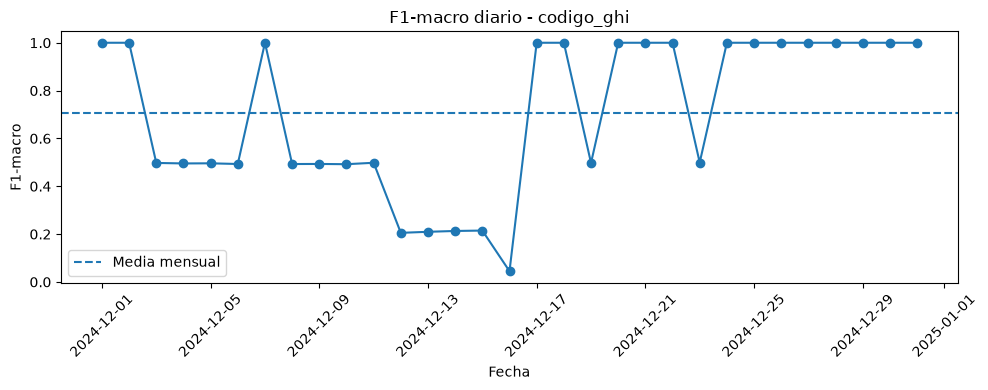

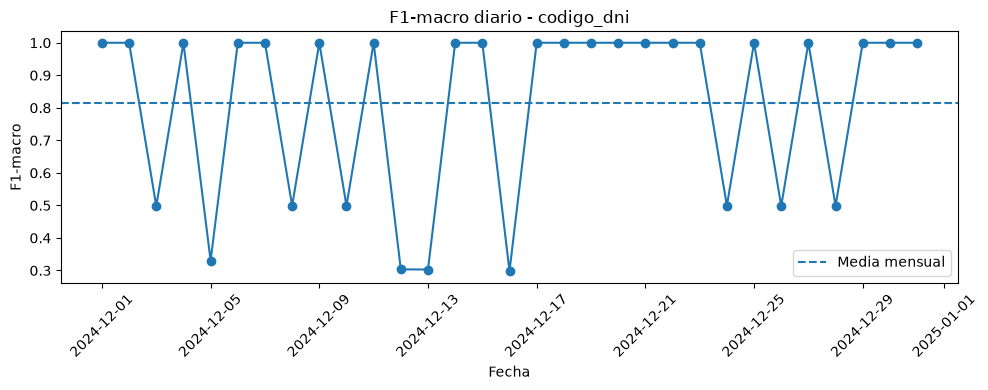

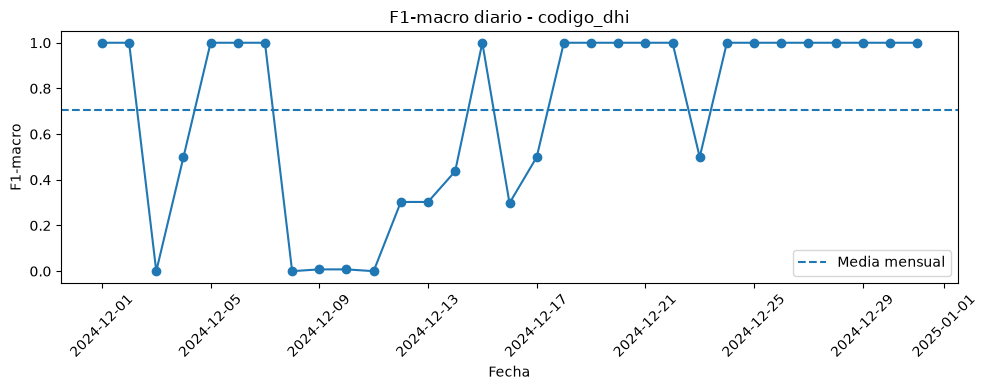

In [84]:
# Evolución diaria del F1-macro

for target in TARGETS:

    target_daily = daily_metrics[
        daily_metrics["target"]
        == target
    ]

    plt.figure(
        figsize=(10, 4)
    )

    plt.plot(
        target_daily["fecha"],
        target_daily["f1_macro"],
        marker="o",
    )

    plt.axhline(
        target_daily[
            "f1_macro"
        ].mean(),
        linestyle="--",
        label="Media mensual",
    )

    plt.title(
        f"F1-macro diario - {target}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("F1-macro")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Detección de comportamiento anómalo

La evolución diaria muestra que el rendimiento no es homogéneo durante todo el mes. Para localizar automáticamente el periodo más problemático, se combina el F1-macro medio de los tres targets con el número total de errores registrados cada día.

Este enfoque no pretende realizar una nueva evaluación de modelos, sino ejemplificar una funcionalidad básica de monitorización que permitiría detectar periodos que requieren revisión en una aplicación real.

In [86]:
# Seleccionar el día globalmente más problemático

worst_day = (
    daily_metrics
    .groupby("fecha", as_index=False)
    .agg(
        mean_f1_macro=(
            "f1_macro",
            "mean",
        ),
        total_errors=(
            "n_errors",
            "sum",
        ),
    )
    .sort_values(
        [
            "mean_f1_macro",
            "total_errors",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .iloc[0]
)

worst_day

fecha            2024-12-16 00:00:00
mean_f1_macro               0.213633
total_errors                    3030
Name: 15, dtype: object

In [87]:
# Recuperar todas las observaciones del día más problemático

worst_day_date = worst_day[
    "fecha"
]

worst_day_predictions = (
    predictions[
        predictions["dia"]
        == worst_day_date
    ]
    .copy()
)

worst_day_predictions.head()

,fecha,codigo_ghi_prob,codigo_ghi_real,codigo_ghi_pred,codigo_dni_real,codigo_dni_pred,codigo_dhi_real,codigo_dhi_pred,dia
21600,2024-12-16 00:00:00,0.010572,1,0,1,1,1,1,2024-12-16
21601,2024-12-16 00:01:00,0.010579,1,0,1,1,1,1,2024-12-16
21602,2024-12-16 00:02:00,0.010586,1,0,1,1,1,1,2024-12-16
21603,2024-12-16 00:03:00,0.010594,1,0,1,1,1,1,2024-12-16
21604,2024-12-16 00:04:00,0.010603,1,0,1,1,1,1,2024-12-16


In [88]:
# Resumen de errores del día seleccionado

worst_day_summary = []

for target in TARGETS:

    y_true = worst_day_predictions[
        f"{target}_real"
    ]

    y_pred = worst_day_predictions[
        f"{target}_pred"
    ]

    metrics = evaluate_predictions(
        y_true=y_true,
        y_pred=y_pred,
        model_name=final_config[target]["model"],
        target=target,
        n_features=len(
            final_config[target]["features"]
        ),
    )

    metrics["n_errors"] = (
        y_true != y_pred
    ).sum()

    worst_day_summary.append(
        metrics
    )

worst_day_summary = pd.DataFrame(
    worst_day_summary
)

worst_day_summary

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted,n_errors
0,MLP,codigo_ghi,14,0.045093,0.047222,0.090186,1372
1,HistGradientBoostingClassifier,codigo_dni,18,0.297903,0.424306,0.595807,829
2,HistGradientBoostingClassifier,codigo_dhi,21,0.297903,0.424306,0.595807,829


In [89]:
# Añadir las variables originales para poder inspeccionar los errores

production_results = (
    df_production
    .merge(
        predictions.drop(
            columns="dia"
        ),
        on="fecha",
        how="left",
    )
)

production_results.head()

,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,...,codigo_ghi,codigo_dni,codigo_dhi,codigo_ghi_prob,codigo_ghi_real,codigo_ghi_pred,codigo_dni_real,codigo_dni_pred,codigo_dhi_real,codigo_dhi_pred
0,2024,-0.5,0.866025,1,0.0,1.0,0,2024-12-01 00:00:00,0.0,0.0,...,0,0,0,0.001495,0,0,0,0,0,0
1,2024,-0.5,0.866025,1,0.0,1.0,1,2024-12-01 00:01:00,0.0,0.0,...,0,0,0,0.001497,0,0,0,0,0,0
2,2024,-0.5,0.866025,1,0.0,1.0,2,2024-12-01 00:02:00,0.0,0.0,...,0,0,0,0.001499,0,0,0,0,0,0
3,2024,-0.5,0.866025,1,0.0,1.0,3,2024-12-01 00:03:00,0.0,0.0,...,0,0,0,0.001501,0,0,0,0,0,0
4,2024,-0.5,0.866025,1,0.0,1.0,4,2024-12-01 00:04:00,0.0,0.0,...,0,0,0,0.001503,0,0,0,0,0,0


In [90]:
worst_day_results = (
    production_results[
        production_results[
            "fecha"
        ]
        .dt.floor("D")
        == worst_day_date
    ]
    .copy()
)

error_mask = np.zeros(
    len(worst_day_results),
    dtype=bool,
)

for target in TARGETS:

    error_mask |= (
        worst_day_results[
            target
        ]
        != worst_day_results[
            f"{target}_pred"
        ]
    )

errors_worst_day = (
    worst_day_results[
        error_mask
    ]
    .copy()
)

print(
    f"Observaciones con algún error: "
    f"{len(errors_worst_day):,} / "
    f"{len(worst_day_results):,}"
)

errors_worst_day[
    [
        "fecha",
        "periodo_solar",
        "ghi",
        "dni",
        "dhi",
        "codigo_ghi",
        "codigo_ghi_pred",
        "codigo_dni",
        "codigo_dni_pred",
        "codigo_dhi",
        "codigo_dhi_pred",
    ]
].head(10)

Observaciones con algún error: 1,372 / 1,440


,fecha,periodo_solar,ghi,dni,dhi,codigo_ghi,codigo_ghi_pred,codigo_dni,codigo_dni_pred,codigo_dhi,codigo_dhi_pred
21600,2024-12-16 00:00:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21601,2024-12-16 00:01:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21602,2024-12-16 00:02:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21603,2024-12-16 00:03:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21604,2024-12-16 00:04:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21605,2024-12-16 00:05:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21606,2024-12-16 00:06:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21607,2024-12-16 00:07:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21608,2024-12-16 00:08:00,noche,0.0,0.0,0.0,1,0,1,1,1,1
21609,2024-12-16 00:09:00,noche,0.0,0.0,0.0,1,0,1,1,1,1


In [93]:
worst_day_class_distribution = []

for target in TARGETS:

    counts = (
        worst_day_results[
            target
        ]
        .value_counts()
        .sort_index()
    )

    for cls, count in counts.items():

        worst_day_class_distribution.append({
            "target": target,
            "class": cls,
            "count": count,
            "percentage": (
                count
                / len(worst_day_results)
                * 100
            ),
        })

worst_day_class_distribution = pd.DataFrame(
    worst_day_class_distribution
)

worst_day_class_distribution

,target,class,count,percentage
0,codigo_ghi,1,1440,100.0
1,codigo_dni,1,1440,100.0
2,codigo_dhi,1,1440,100.0


### Análisis del 16 de diciembre

El 16 de diciembre es identificado como el día más problemático, con un F1-macro medio de `0.214` y 3.030 errores acumulados entre los tres targets.

La inspección revela además una característica excepcional: **las 1.440 observaciones del día pertenecen a la clase `1` para GHI, DNI y DHI**. Esta situación contrasta fuertemente con la distribución habitual del resto del mes.

En GHI, 1.372 de las 1.440 observaciones son clasificadas incorrectamente. La inspección muestra incluso periodos nocturnos con `GHI = DNI = DHI = 0` etiquetados como clase `1`, mientras que el modelo de GHI los clasifica como `0`.

Por tanto, el deterioro observado ese día no debe interpretarse exclusivamente como una pérdida general de capacidad predictiva. El pipeline ha permitido detectar un **cambio excepcional en el patrón de etiquetas**, que en un entorno real debería activar una revisión de la calidad de los datos, del proceso de etiquetado o de las condiciones específicas de esa jornada.

Este caso ilustra una utilidad adicional de la solución End-to-End: además de generar predicciones, la monitorización temporal permite identificar automáticamente situaciones alejadas del comportamiento habitual.

In [91]:
OUTPUT_PATH = Path(
    "../outputs/end_to_end"
)

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

production_output = (
    predictions
    .drop(
        columns="dia"
    )
    .copy()
)

production_output.to_parquet(
    OUTPUT_PATH
    / "predictions_december_2024.parquet",
    index=False,
)

monthly_metrics.to_csv(
    OUTPUT_PATH
    / "monthly_metrics.csv",
    index=False,
)

daily_metrics.to_csv(
    OUTPUT_PATH
    / "daily_metrics.csv",
    index=False,
)

comparison.to_csv(
    OUTPUT_PATH
    / "metrics_comparison.csv",
    index=False,
)

print(
    "Resultados End-to-End guardados correctamente."
)

Resultados End-to-End guardados correctamente.


## 17.6. Conclusiones

La simulación End-to-End demuestra que los modelos seleccionados pueden integrarse en un flujo único que abarca la preparación de nuevos datos, el reentrenamiento final, la inferencia, la evaluación temporal y la persistencia de resultados.

El escenario de diciembre muestra, además, que el rendimiento agregado no es suficiente para evaluar el funcionamiento operativo de la solución. La monitorización diaria permite detectar cambios importantes en la distribución de las etiquetas, como el observado el 16 de diciembre, y diferenciar estos casos de una degradación general del modelo.

La principal aportación de este notebook no consiste en mejorar nuevamente los algoritmos, sino en demostrar cómo los componentes desarrollados durante el proyecto pueden utilizarse conjuntamente como una **solución reproducible de clasificación y monitorización de la calidad de las mediciones de irradiancia**.

Como limitación, esta prueba constituye una simulación retrospectiva sobre datos ya disponibles durante el desarrollo global del proyecto y no una validación prospectiva sobre nuevas mediciones adquiridas después de finalizar los modelos. Una validación futura con nuevos datos permitiría evaluar de forma más rigurosa la estabilidad temporal y detectar posibles fenómenos de *data drift* o *concept drift*.